Name : Suyog Bastakoti

Uni ID: 2407093

In [2]:
!pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 6.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.8 MB/s eta 0:00:00


Cell 1 — Imports

In [3]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Text preprocessing
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import contractions

# Visualization
from wordcloud import WordCloud

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

# Word2Vec
from gensim.models import Word2Vec

# Download NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("All libraries imported successfully!")

2026-05-09 08:05:33.845051: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778313934.296876      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778313934.418630      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778313935.403592      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778313935.403634      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778313935.403640      57 computation_placer.cc:177] computation placer alr

All libraries imported successfully!


Cell 2 — Load & Explore the Dataset

In [4]:
# Load dataset
df = pd.read_csv('/kaggle/input/datasets/sbmusicclub/hatespeech-dataset/hatevsoffensive_language.csv')

# Basic info
print("Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (24783, 2)

Column Names: ['label', 'text']

First 5 rows:


,label,text
0,neither,!!! RT @mayasolovely: As a woman you shouldn't...
1,offensive language,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,offensive language,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,offensive language,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,offensive language,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


Cell -3 Class Distribution

Class Distribution:
label
offensive language    19190
neither                4163
hate speec             1430
Name: count, dtype: int64

Class Percentages:
label
offensive language    77.432111
neither               16.797805
hate speec             5.770084
Name: proportion, dtype: float64


/tmp/ipykernel_57/3598307321.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='Set2')


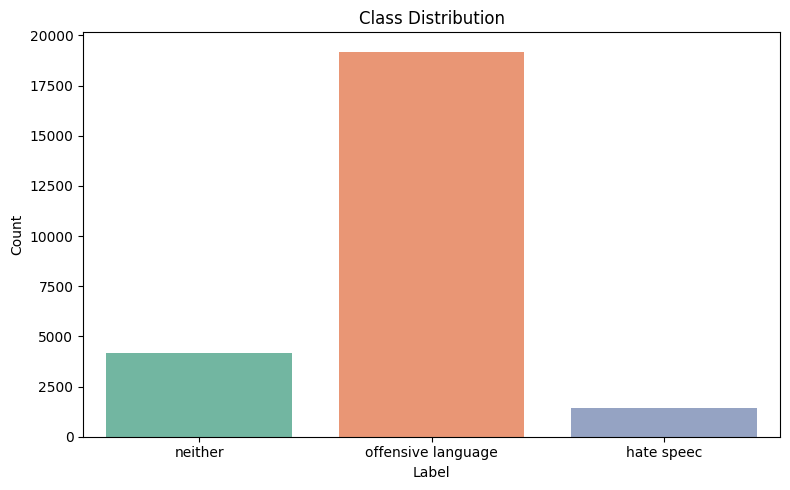

In [5]:
# Class distribution
print("Class Distribution:")
print(df['label'].value_counts())
print("\nClass Percentages:")
print(df['label'].value_counts(normalize=True) * 100)

# Plot class distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='label', palette='Set2')
plt.title('Class Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [6]:
# Fix typo in label
df['label'] = df['label'].str.strip()  # remove any extra spaces
df['label'] = df['label'].replace('hate speec', 'hate speech')

# Verify fix
print("Labels after fix:")
print(df['label'].value_counts())

# Encode labels to numbers
# hate speech = 0, offensive language = 1, neither = 2
label_map = {'hate speech': 0, 'offensive language': 1, 'neither': 2}
df['label_encoded'] = df['label'].map(label_map)

print("\nEncoded label distribution:")
print(df['label_encoded'].value_counts().sort_index())
print("\nSample rows:")
df[['label', 'label_encoded']].head(10)

Labels after fix:
label
offensive language    19190
neither                4163
hate speech            1430
Name: count, dtype: int64

Encoded label distribution:
label_encoded
0     1430
1    19190
2     4163
Name: count, dtype: int64

Sample rows:


,label,label_encoded
0,neither,2
1,offensive language,1
2,offensive language,1
3,offensive language,1
4,offensive language,1
5,offensive language,1
6,offensive language,1
7,offensive language,1
8,offensive language,1
9,offensive language,1


Cell 4 — Text Preprocessing & Cleaning

In [11]:
# Updated clean function with amp fix
def clean_text(text):
    text = text.lower()
    text = contractions.fix(text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'\brt\b', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'&amp;|&lt;|&gt;|&quot;', '', text)  # fix HTML entities
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# Re-apply
print("Re-cleaning text...")
df['cleaned_text'] = df['text'].apply(clean_text)
print("Done!")



Re-cleaning text...
Done!


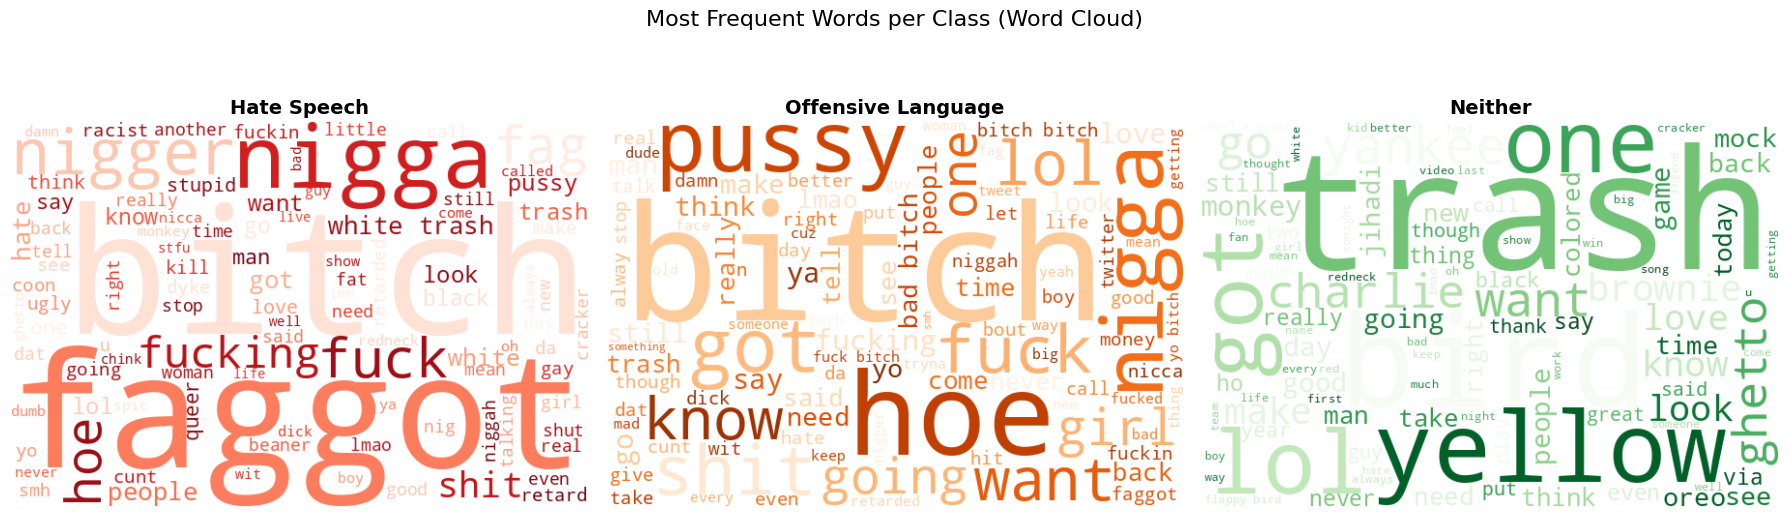

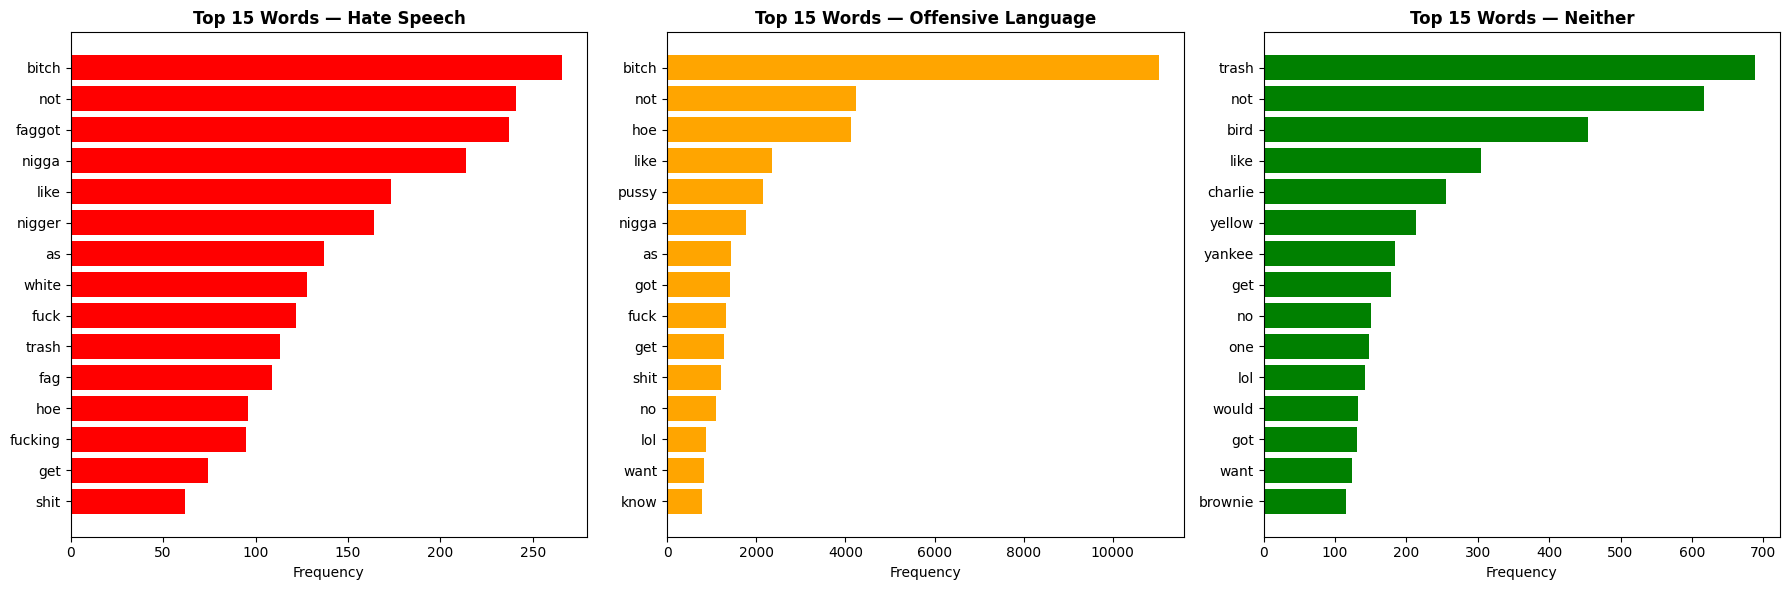

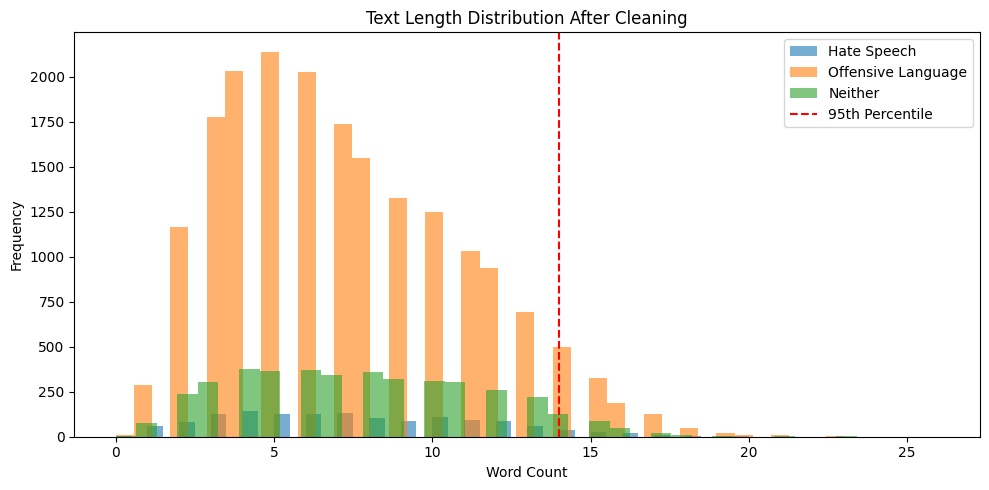


Text length stats:
count    24783.000000
mean         7.304120
std          3.766824
min          0.000000
25%          4.000000
50%          7.000000
75%         10.000000
max         26.000000
Name: text_length, dtype: float64

95th percentile length: 14 words


In [12]:
# ---- VISUALIZATION ----

# 1. Word Cloud per class
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
classes = {0: 'Hate Speech', 1: 'Offensive Language', 2: 'Neither'}
colors = {0: 'Reds', 1: 'Oranges', 2: 'Greens'}

for label, name in classes.items():
    text_blob = ' '.join(df[df['label_encoded'] == label]['cleaned_text'])
    wordcloud = WordCloud(
        width=600, height=400,
        background_color='white',
        colormap=colors[label],
        max_words=100
    ).generate(text_blob)
    axes[label].imshow(wordcloud, interpolation='bilinear')
    axes[label].axis('off')
    axes[label].set_title(f'{name}', fontsize=14, fontweight='bold')

plt.suptitle('Most Frequent Words per Class (Word Cloud)', fontsize=16)
plt.tight_layout()
plt.show()

# 2. Top 15 most frequent words per class
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
bar_colors = {0: 'red', 1: 'orange', 2: 'green'}

for label, name in classes.items():
    text_blob = ' '.join(df[df['label_encoded'] == label]['cleaned_text'])
    word_freq = Counter(text_blob.split()).most_common(15)
    words, counts = zip(*word_freq)
    axes[label].barh(words, counts, color=bar_colors[label])
    axes[label].invert_yaxis()
    axes[label].set_title(f'Top 15 Words — {name}', fontsize=12, fontweight='bold')
    axes[label].set_xlabel('Frequency')

plt.tight_layout()
plt.show()

# 3. Text length distribution after cleaning
df['text_length'] = df['cleaned_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 5))
for label, name in classes.items():
    subset = df[df['label_encoded'] == label]['text_length']
    plt.hist(subset, bins=40, alpha=0.6, label=name)

plt.axvline(df['text_length'].quantile(0.95), color='red', linestyle='--', label='95th Percentile')
plt.title('Text Length Distribution After Cleaning')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nText length stats:")
print(df['text_length'].describe())
print(f"\n95th percentile length: {int(df['text_length'].quantile(0.95))} words")

Cell 6 — Tokenization & Padding:

In [13]:
# Train/Test split (80/20 stratified)
X = df['cleaned_text']
y = df['label_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print(f"\nTrain class distribution:\n{y_train.value_counts().sort_index()}")
print(f"\nTest class distribution:\n{y_test.value_counts().sort_index()}")

# Tokenization
MAX_WORDS = 20000  # vocabulary size
MAX_LEN = 14       # 95th percentile from previous cell

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)  # fit only on training data

# Convert to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

# One-hot encode labels for Keras
y_train_cat = to_categorical(y_train, num_classes=3)
y_test_cat = to_categorical(y_test, num_classes=3)

print(f"\nVocabulary size: {len(tokenizer.word_index)}")
print(f"X_train shape: {X_train_pad.shape}")
print(f"X_test shape: {X_test_pad.shape}")
print(f"y_train shape: {y_train_cat.shape}")

Train size: 19826, Test size: 4957

Train class distribution:
label_encoded
0     1144
1    15352
2     3330
Name: count, dtype: int64

Test class distribution:
label_encoded
0     286
1    3838
2     833
Name: count, dtype: int64

Vocabulary size: 15961
X_train shape: (19826, 14)
X_test shape: (4957, 14)
y_train shape: (19826, 3)


Cell 7 — Class Weights

In [14]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))
print("Class Weights:")
for k, v in class_weight_dict.items():
    labels = {0: 'Hate Speech', 1: 'Offensive Language', 2: 'Neither'}
    print(f"  {labels[k]}: {v:.4f}")

Class Weights:
  Hate Speech: 5.7768
  Offensive Language: 0.4305
  Neither: 1.9846


Cell 8 — Model 1: Simple RNN with Trainable Embedding:

In [15]:
from tensorflow.keras.layers import Bidirectional

# Shared config
VOCAB_SIZE = 20000
EMBED_DIM = 64
MAX_LEN = 14

# ── MODEL 1: SimpleRNN ──
model1 = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
    SimpleRNN(64, return_sequences=False),
    Dropout(0.3),
    Dense(3, activation='softmax')
], name='SimpleRNN_Model')

model1.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1778315208.990410      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778315208.996400      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Cell 9 — Train Model 1:

In [16]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history1 = model1.fit(
    X_train_pad, y_train_cat,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

print("\nModel 1 (SimpleRNN) Training Complete!")

Epoch 1/20


I0000 00:00:1778315267.626789     216 service.cc:152] XLA service 0x7d2a600052c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778315267.626841     216 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778315267.626845     216 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778315268.418280     216 cuda_dnn.cc:529] Loaded cuDNN version 91002


 46/279 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3698 - loss: 1.1045

I0000 00:00:1778315270.783706     216 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


279/279 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5811 - loss: 0.9365 - val_accuracy: 0.7675 - val_loss: 0.5990
Epoch 2/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8471 - loss: 0.3969 - val_accuracy: 0.7368 - val_loss: 0.6354
Epoch 3/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9059 - loss: 0.2261 - val_accuracy: 0.7600 - val_loss: 0.6314
Epoch 4/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9496 - loss: 0.1195 - val_accuracy: 0.7761 - val_loss: 0.6557

Model 1 (SimpleRNN) Training Complete!


Cell 10 — Plot Model 1 Training Curves:

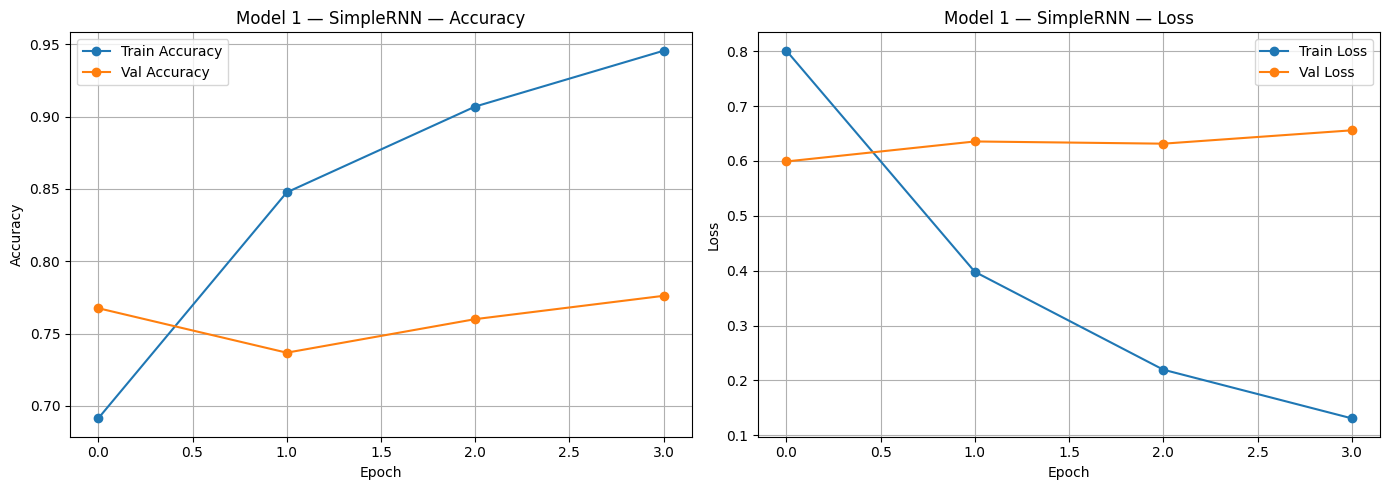

In [17]:
def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Accuracy
    axes[0].plot(history.history['accuracy'], label='Train Accuracy', marker='o')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', marker='o')
    axes[0].set_title(f'{model_name} — Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)
    
    # Loss
    axes[1].plot(history.history['loss'], label='Train Loss', marker='o')
    axes[1].plot(history.history['val_loss'], label='Val Loss', marker='o')
    axes[1].set_title(f'{model_name} — Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()

plot_history(history1, 'Model 1 — SimpleRNN')

Cell 11 — Model 2: LSTM with Trainable Embedding

In [18]:
model2 = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(3, activation='softmax')
], name='LSTM_Model')

model2.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model2.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Cell 12 — Train Model 2

In [19]:
early_stop2 = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history2 = model2.fit(
    X_train_pad, y_train_cat,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    class_weight=class_weight_dict,
    callbacks=[early_stop2],
    verbose=1
)

print("\nModel 2 (LSTM) Training Complete!")

Epoch 1/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.7040 - loss: 0.8921 - val_accuracy: 0.8185 - val_loss: 0.5077
Epoch 2/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8260 - loss: 0.4793 - val_accuracy: 0.8084 - val_loss: 0.5201
Epoch 3/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8616 - loss: 0.3287 - val_accuracy: 0.8139 - val_loss: 0.4715
Epoch 4/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9083 - loss: 0.2227 - val_accuracy: 0.7695 - val_loss: 0.6197
Epoch 5/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9269 - loss: 0.1674 - val_accuracy: 0.8538 - val_loss: 0.4759
Epoch 6/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9417 - loss: 0.1352 - val_accuracy: 0.7786 - val_loss: 0.7607

Model 2 (LSTM) Training Complete!


Cell 13 — Plot Model 2:

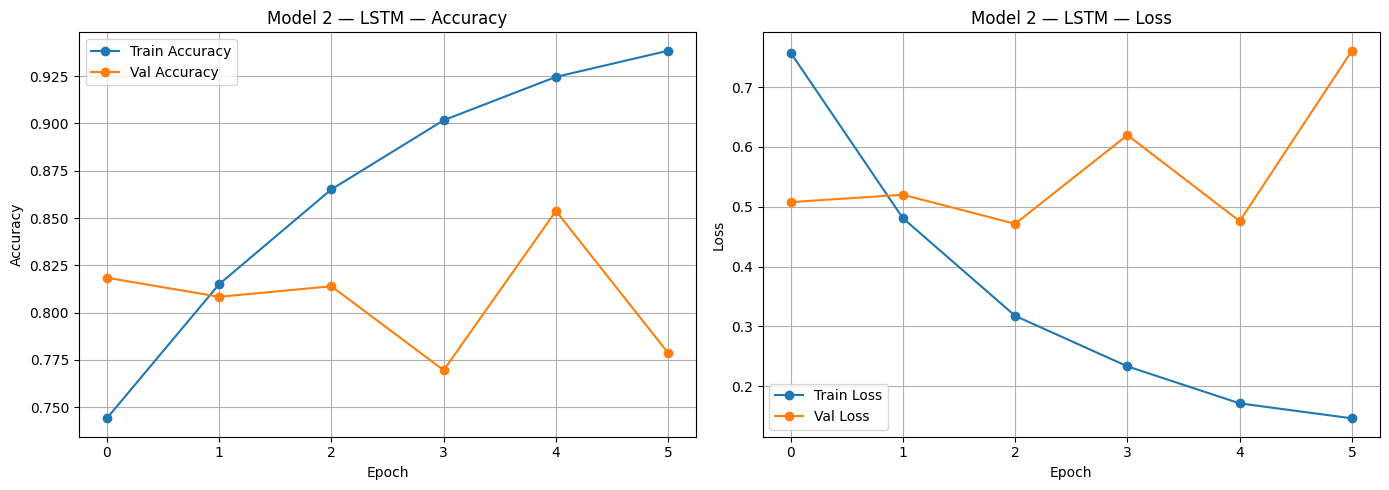

In [20]:
plot_history(history2, 'Model 2 — LSTM')

Cell 14 — Train Word2Vec on Training Data

In [21]:
from gensim.models import Word2Vec

# Tokenize cleaned training text into list of word lists for Word2Vec
w2v_training_data = [text.split() for text in X_train]

# Train Word2Vec model
w2v_model = Word2Vec(
    sentences=w2v_training_data,
    vector_size=EMBED_DIM,  # must match EMBED_DIM = 64
    window=5,
    min_count=1,
    workers=4,
    epochs=10
)

print(f"Word2Vec trained!")
print(f"Vocabulary size: {len(w2v_model.wv)}")
print(f"\nSample — vector for 'hate' (first 5 dims): {w2v_model.wv['hate'][:5]}")

Word2Vec trained!
Vocabulary size: 15960

Sample — vector for 'hate' (first 5 dims): [ 0.98333687 -0.95055276  1.0758564   1.0243841  -0.27719048]


Cell 15 — Build Embedding Matrix

In [22]:
# Build embedding matrix using Word2Vec weights
vocab_size_actual = min(MAX_WORDS, len(tokenizer.word_index) + 1)

embedding_matrix = np.zeros((vocab_size_actual, EMBED_DIM))

matched = 0
for word, idx in tokenizer.word_index.items():
    if idx < vocab_size_actual:
        if word in w2v_model.wv:
            embedding_matrix[idx] = w2v_model.wv[word]
            matched += 1

print(f"Total tokens in tokenizer: {vocab_size_actual}")
print(f"Tokens matched in Word2Vec: {matched}")
print(f"Embedding matrix shape: {embedding_matrix.shape}")

Total tokens in tokenizer: 15962
Tokens matched in Word2Vec: 15960
Embedding matrix shape: (15962, 64)


Cell 16 — Build Model 3: LSTM + Word2Vec

In [23]:
model3 = Sequential([
    Embedding(
        input_dim=vocab_size_actual,
        output_dim=EMBED_DIM,
        weights=[embedding_matrix],
        trainable=False  # freeze pretrained weights
    ),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(3, activation='softmax')
], name='LSTM_Word2Vec_Model')

model3.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model3.summary()

Model: "LSTM_Word2Vec_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     1,021,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,021,568 (3.90 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,021,568 (3.90 MB)

Cell 17 — Train Model 3

In [24]:
early_stop3 = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history3 = model3.fit(
    X_train_pad, y_train_cat,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    class_weight=class_weight_dict,
    callbacks=[early_stop3],
    verbose=1
)

print("\nModel 3 (LSTM + Word2Vec) Training Complete!")

Epoch 1/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6991 - loss: 0.8899 - val_accuracy: 0.7912 - val_loss: 0.6383
Epoch 2/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7818 - loss: 0.6638 - val_accuracy: 0.8144 - val_loss: 0.5370
Epoch 3/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7947 - loss: 0.6464 - val_accuracy: 0.7690 - val_loss: 0.5896
Epoch 4/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8019 - loss: 0.6089 - val_accuracy: 0.8190 - val_loss: 0.5008
Epoch 5/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7949 - loss: 0.6052 - val_accuracy: 0.8210 - val_loss: 0.4957
Epoch 6/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7969 - loss: 0.6099 - val_accuracy: 0.7600 - val_loss: 0.6517
Epoch 7/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7993 - loss: 0.5826 - val_accuracy: 0.8058 - val_loss: 0.5222
Epoch 8/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7883 - loss: 0.5907 - val_accuracy: 0.

Cell 18 — Plot Model 3 & Compare All 3

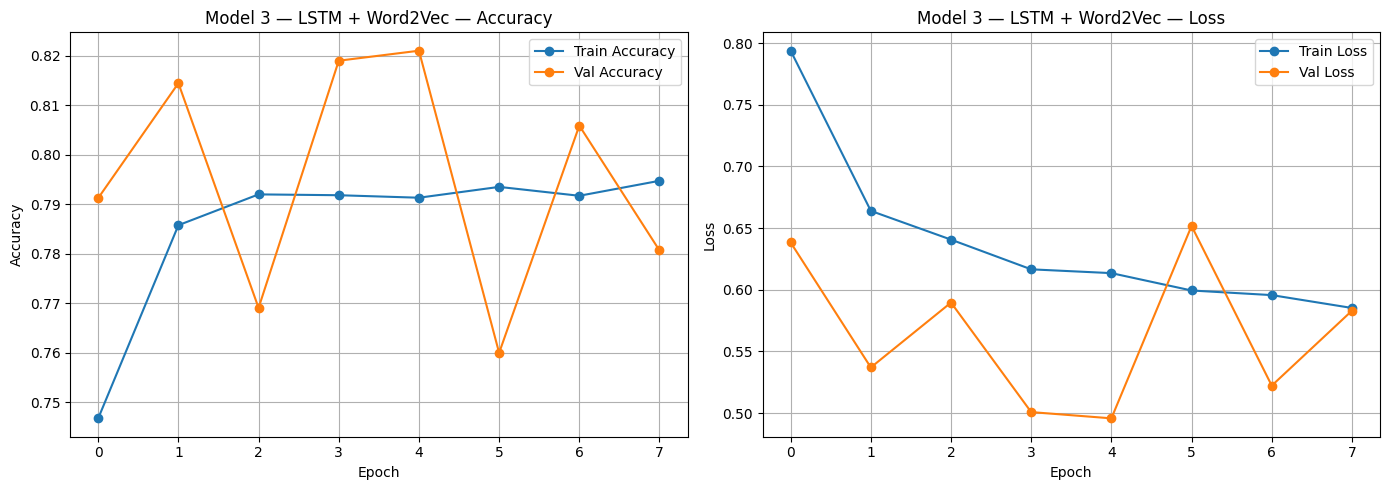

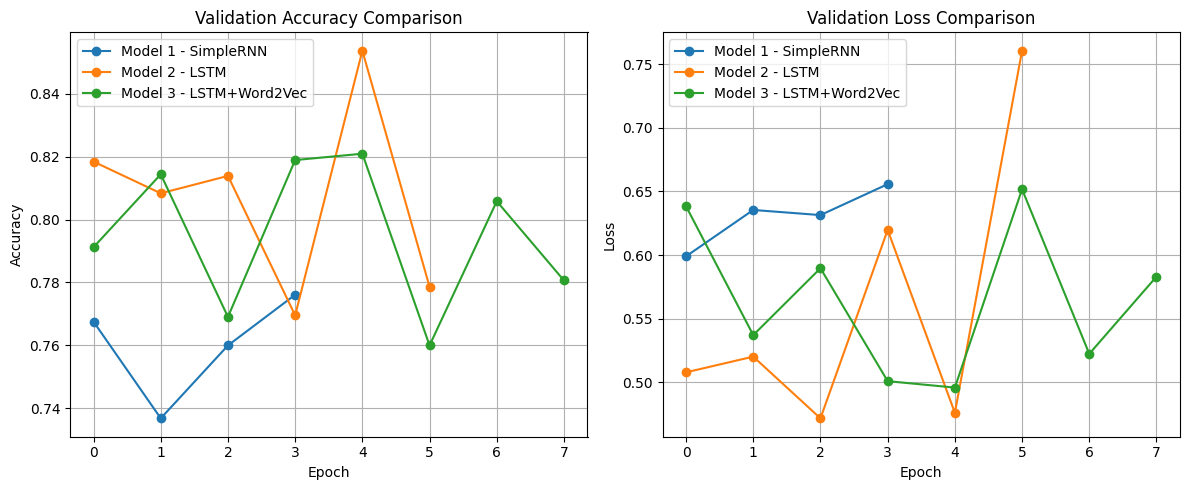

In [25]:
# Plot Model 3
plot_history(history3, 'Model 3 — LSTM + Word2Vec')

# Compare all 3 models - Validation Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history1.history['val_accuracy'], label='Model 1 - SimpleRNN', marker='o')
plt.plot(history2.history['val_accuracy'], label='Model 2 - LSTM', marker='o')
plt.plot(history3.history['val_accuracy'], label='Model 3 - LSTM+Word2Vec', marker='o')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history1.history['val_loss'], label='Model 1 - SimpleRNN', marker='o')
plt.plot(history2.history['val_loss'], label='Model 2 - LSTM', marker='o')
plt.plot(history3.history['val_loss'], label='Model 3 - LSTM+Word2Vec', marker='o')
plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Cell 19 — Evaluate All 3 Models:


  Model 1 - SimpleRNN

Test Accuracy: 0.7694

Classification Report:
                    precision    recall  f1-score   support

       Hate Speech       0.19      0.68      0.30       286
Offensive Language       0.96      0.77      0.86      3838
           Neither       0.77      0.80      0.78       833

          accuracy                           0.77      4957
         macro avg       0.64      0.75      0.64      4957
      weighted avg       0.89      0.77      0.81      4957



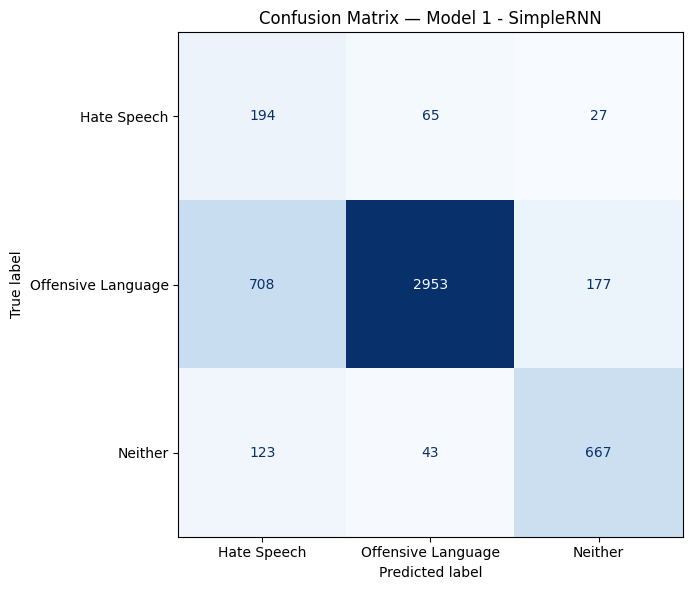


  Model 2 - LSTM

Test Accuracy: 0.8063

Classification Report:
                    precision    recall  f1-score   support

       Hate Speech       0.23      0.62      0.34       286
Offensive Language       0.94      0.83      0.88      3838
           Neither       0.78      0.76      0.77       833

          accuracy                           0.81      4957
         macro avg       0.65      0.74      0.66      4957
      weighted avg       0.87      0.81      0.83      4957



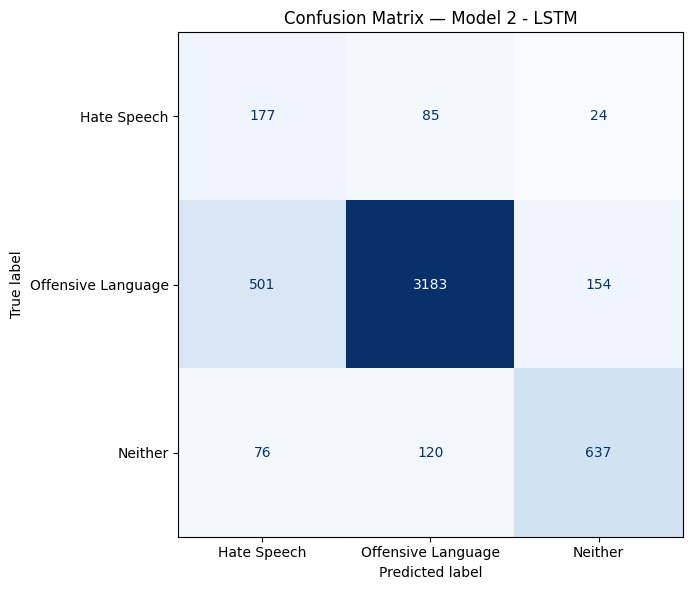


  Model 3 - LSTM + Word2Vec

Test Accuracy: 0.8160

Classification Report:
                    precision    recall  f1-score   support

       Hate Speech       0.24      0.48      0.32       286
Offensive Language       0.97      0.82      0.89      3838
           Neither       0.67      0.93      0.78       833

          accuracy                           0.82      4957
         macro avg       0.63      0.74      0.66      4957
      weighted avg       0.88      0.82      0.84      4957



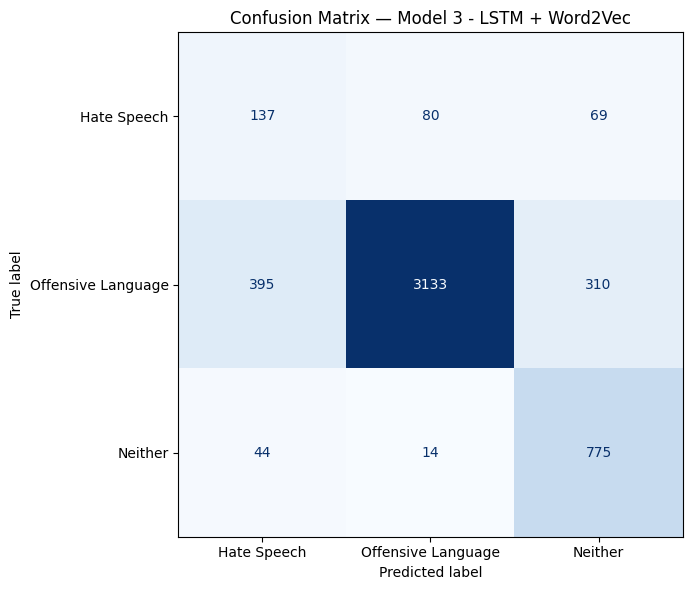

In [26]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

models = {
    'Model 1 - SimpleRNN': model1,
    'Model 2 - LSTM': model2,
    'Model 3 - LSTM + Word2Vec': model3
}

class_names = ['Hate Speech', 'Offensive Language', 'Neither']

for model_name, model in models.items():
    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")
    
    # Predictions
    y_pred_prob = model.predict(X_test_pad, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = np.argmax(y_test_cat, axis=1)
    
    # Accuracy
    acc = np.mean(y_pred == y_true)
    print(f"\nTest Accuracy: {acc:.4f}")
    
    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix — {model_name}')
    plt.tight_layout()
    plt.show()

Cell 20 — Error Analysis:

In [27]:
# Use Model 3 (best model) for error analysis
y_pred_prob = model3.predict(X_test_pad, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

# Get original text for test set
X_test_original = df.loc[X_test.index, 'text'].values
X_test_cleaned = X_test.values

# Find misclassified examples
misclassified_idx = np.where(y_pred != y_true)[0]

print(f"Total misclassified: {len(misclassified_idx)} out of {len(y_true)}")
print(f"Error rate: {len(misclassified_idx)/len(y_true)*100:.2f}%\n")

# Show 3 misclassified examples
print("="*70)
print("MISCLASSIFIED EXAMPLES")
print("="*70)

shown = 0
for idx in misclassified_idx:
    true_label = class_names[y_true[idx]]
    pred_label = class_names[y_pred[idx]]
    
    # Only show interesting cases involving hate speech
    if y_true[idx] == 0 or y_pred[idx] == 0:
        print(f"\nExample {shown+1}:")
        print(f"  Original Text : {X_test_original[idx]}")
        print(f"  Cleaned Text  : {X_test_cleaned[idx]}")
        print(f"  True Label    : {true_label}")
        print(f"  Predicted     : {pred_label}")
        print(f"  Confidence    : {y_pred_prob[idx][y_pred[idx]]:.4f}")
        print("-"*70)
        shown += 1
        if shown == 3:
            break

Total misclassified: 912 out of 4957
Error rate: 18.40%

MISCLASSIFIED EXAMPLES

Example 1:
  Original Text : RT @JimNorton: There is a GIFT SHOP at the 9-11 museum? And they charge admission. It's a mass grave you fucking cunts. What a disgrace.
  Cleaned Text  : gift shop museum charge admission mass grave fucking cunt disgrace
  True Label    : Offensive Language
  Predicted     : Hate Speech
  Confidence    : 0.7616
----------------------------------------------------------------------

Example 2:
  Original Text : @MakEitSndGoOd @Fewjr we block us then and see what happens. You think we on ya high yellow ass now. Just watch
  Cleaned Text  : block u see happens think ya high yellow as watch
  True Label    : Offensive Language
  Predicted     : Hate Speech
  Confidence    : 0.4967
----------------------------------------------------------------------

Example 3:
  Original Text : "@poppunksucks: Twitter is not a source of news broadcast you fucking retards" it is when nbc, abc, cn

Cell 21 — Error Analysis Summary Plot:

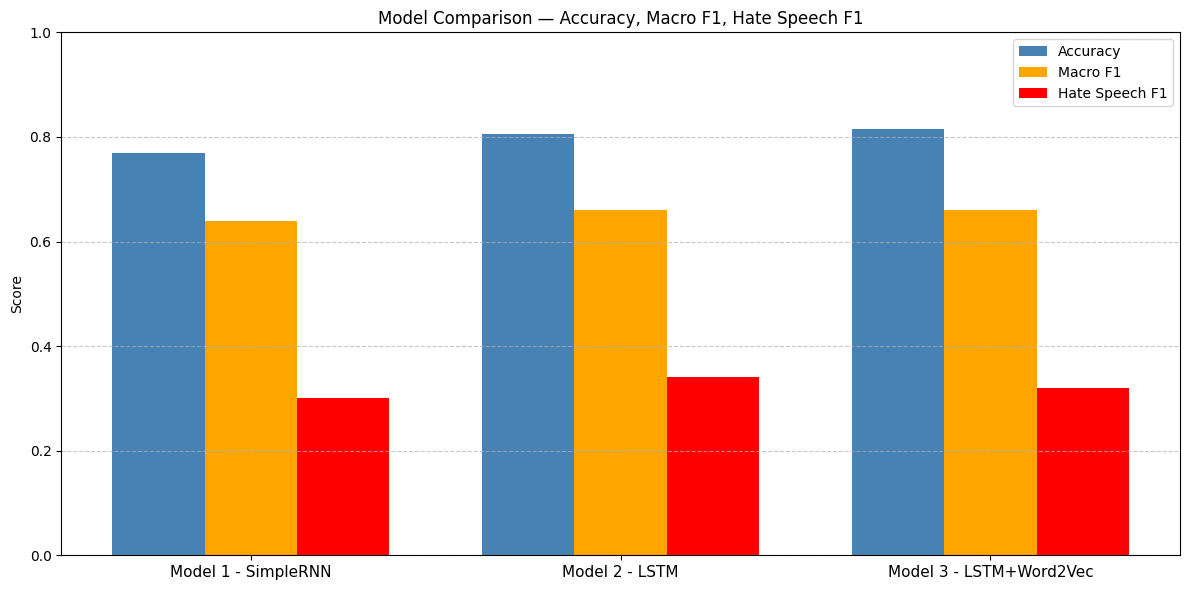

In [29]:
# Model Comparison Bar Chart
metrics = {
    'Model 1 - SimpleRNN': {'Accuracy': 0.7694, 'Macro F1': 0.64, 'Hate Speech F1': 0.30},
    'Model 2 - LSTM': {'Accuracy': 0.8063, 'Macro F1': 0.66, 'Hate Speech F1': 0.34},
    'Model 3 - LSTM+Word2Vec': {'Accuracy': 0.8160, 'Macro F1': 0.66, 'Hate Speech F1': 0.32},
}

x = np.arange(3)
width = 0.25
labels = list(metrics.keys())
accuracy = [m['Accuracy'] for m in metrics.values()]
macro_f1 = [m['Macro F1'] for m in metrics.values()]
hs_f1 = [m['Hate Speech F1'] for m in metrics.values()]

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, accuracy, width, label='Accuracy', color='steelblue')
ax.bar(x, macro_f1, width, label='Macro F1', color='orange')
ax.bar(x + width, hs_f1, width, label='Hate Speech F1', color='red')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Accuracy, Macro F1, Hate Speech F1')
ax.legend()
ax.set_ylim(0, 1.0)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Final Cell — Gradio GUI

In [30]:
!pip install gradio -q

import gradio as gr

def predict_tweet(tweet):
    # Clean the input
    cleaned = clean_text(tweet)
    
    # Tokenize and pad
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    
    # Predict using Model 3 (best model)
    pred_prob = model3.predict(padded, verbose=0)[0]
    pred_class = np.argmax(pred_prob)
    
    # Format output
    result = {
        'Hate Speech': float(pred_prob[0]),
        'Offensive Language': float(pred_prob[1]),
        'Neither': float(pred_prob[2])
    }
    
    return result

# Launch GUI
demo = gr.Interface(
    fn=predict_tweet,
    inputs=gr.Textbox(
        lines=3,
        placeholder="Type or paste a tweet here...",
        label="Input Tweet"
    ),
    outputs=gr.Label(
        num_top_classes=3,
        label="Prediction"
    ),
    title="Hate Speech Detector — STChange9",
    description="Enter a tweet to classify it as Hate Speech, Offensive Language, or Neither. Powered by LSTM + Word2Vec.",
    examples=[
        ["I love how diverse our community is!"],
        ["You are such an idiot, go to hell"],
        ["People like you should not exist in this world"]
    ]
)

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://6434275ae7320a98b8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
